# 23d — side-diagnostic: does the TARGET FILTER explain the σ collapse?

**Question (Anuar).** The dataset CRB in 23a/23b collapses by ~√N × kernel. We identified a third suspect:
the **target filter** `fit_err/FWHM < 10` applied when loading the real data (it removes 0.2–0.6 % of rows at
high T, but **33–62 %** at low T, and those are the extreme σ_fit tail — the dropped 3nW T40 rows have median
FWHM 0.13 MHz and median fit error 11 204 MHz).

**What this notebook does.** At each of the 14 optima found by **23a**, it recomputes the Fisher/CRB under
different treatments of the two clouds, holding the optimum and the likelihood fixed:

| variant | target (real) | simulated cloud |
|---|---|---|
| **V0** baseline | filtered (`err/f < 10`) | as simulated (matches 23a) |
| **V1** | **UNfiltered** (all valid rows) | as simulated |
| **V2** | filtered | **filtered by the same rule** (`σ_fit/FWHM < 10`) |

V1 asks *"how much of σ comes from conditioning the target?"*; V2 asks *"what if the simulator were filtered
the same way?"*. Also reported: the **drop rates** of both clouds (the asymmetry is the point).

In [1]:
# ============================================================
# 23d — imports, 23a's optima, and the two target loaders
# ============================================================
import json, math, os, sys, time
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
import multiprocessing as _mp
from concurrent.futures import ProcessPoolExecutor as _PPE

torch.set_default_dtype(torch.float32)
for _p in [os.getcwd(), os.path.join(os.getcwd(), '..'), os.path.join(os.getcwd(), '..', '..')]:
    if os.path.isdir(os.path.join(_p, 'src')):
        sys.path.insert(0, _p); REPO_ROOT = _p; break
os.chdir(REPO_ROOT)

from src.fitting import fit_profile, fwhm_from_theta, nll
from src.samplers import draw_fixed_noise
from src.implicit import compute_fwhm_and_dgamma

A_JSON = os.path.join(REPO_ROOT, 'data', 'processed', '23a_fisher_exp6_trial07.json')
OUT    = os.path.join(REPO_ROOT, 'data', 'processed', '23d_sigma_collapse.json')
CSV    = os.path.join(REPO_ROOT, 'data', 'processed', 'fwhm_linewidths.csv')

_d23a = json.load(open(A_JSON))
OPT = {r['exp']: dict(mu=r['mu_final'], gamma=r['gamma_final'], sigma_prop=r['sigma_prop'],
                      lam=r['lam'], power=r['power'], mu_true=r['mu_true'], gamma_true=r['gamma_true'])
       for r in _d23a['results']}
REC_B = {t['exp']: t['sig_mu_data'] for t in _d23a['table']}      # 23a's recorded dataset CRB (for the sanity check)
DF = pd.read_csv(CSV)
print(f'loaded {len(OPT)} optima from 23a; CSV rows {len(DF)}')

def load_target(exp, filtered=True):
    p = int(str(OPT[exp]['power']).replace('nW', '')); t = int(str(exp).split('Trans')[-1])
    sub = DF[(DF.power_nW == p) & (DF.transmission == t)]
    f = sub['fwhm'].to_numpy(float) * 1000.0
    e = sub['fit_error'].to_numpy(float) * 1000.0
    with np.errstate(invalid='ignore', divide='ignore'):
        ok = np.isfinite(f) & np.isfinite(e) & (f > 0)
        keep = ok & ((e / f) < 10.0) if filtered else ok
    return f[keep], e[keep]

def load_target_sub(exp, n_keep, seed=1234):
    # the UNfiltered target, randomly subsampled to `n_keep` rows -> same N, unfiltered shape
    f0, e0 = load_target(exp, False)
    if len(f0) <= n_keep:
        return f0, e0
    rng = np.random.default_rng(seed)
    idx = np.sort(rng.choice(len(f0), size=n_keep, replace=False))
    return f0[idx], e0[idx]

def scott_h(tf, ts, h_s_min=0.05):
    sc = len(tf) ** (-1.0 / 6.0)
    return float(tf.std()) * sc, max(float(ts.std()) * sc, h_s_min)

nf, nu = {}, {}
for e in OPT:
    f1, s1 = load_target(e, True); f0, s0 = load_target(e, False)
    nf[e] = len(f1); nu[e] = len(f0)
    print(f'  {e:13s} valid {len(f0):5d} -> kept {len(f1):5d}  (drops {100*(1-len(f1)/len(f0)):5.1f}%)')


loaded 14 optima from 23a; CSV rows 46400
  1nW Trans05   valid   161 -> kept    61  (drops  62.1%)
  1nW Trans10   valid   531 -> kept   358  (drops  32.6%)
  1nW Trans20   valid  1277 -> kept  1138  (drops  10.9%)
  1nW Trans40   valid  2443 -> kept  2428  (drops   0.6%)
  1nW Trans60   valid  2428 -> kept  2424  (drops   0.2%)
  1nW Trans80   valid  2494 -> kept  2487  (drops   0.3%)
  1nW Trans100  valid  2461 -> kept  2455  (drops   0.2%)
  3nW Trans05   valid   390 -> kept   252  (drops  35.4%)
  3nW Trans10   valid  1650 -> kept  1572  (drops   4.7%)
  3nW Trans20   valid  2205 -> kept  2171  (drops   1.5%)
  3nW Trans40   valid  3763 -> kept  3742  (drops   0.6%)
  3nW Trans60   valid  2548 -> kept  2541  (drops   0.3%)
  3nW Trans80   valid  2519 -> kept  2508  (drops   0.4%)
  3nW Trans100  valid  2525 -> kept  2516  (drops   0.4%)


In [2]:
# ============================================================
# 23d — simulation + Fisher (same machinery as 23a, so V0 must reproduce its numbers)
# ============================================================
M_FINAL, FISHER_SEEDS, FISHER_BASE_SEED = 400, 3, 7000
N_WORKERS = 2          # 23c is using the other cores
SMOKE = os.environ.get('NB_SMOKE') == '1'
if SMOKE:
    M_FINAL, FISHER_SEEDS = 40, 1
    OPT = {k: OPT[k] for k in list(OPT)[:2]}
    print('*** SMOKE: 2 experiments, M=40, 1 seed ***')

def _kde_scores(sim_f, sim_s, sim_n, sim_df, sim_ds, data_f, data_s, h_f, h_s, mu, sigma_prop, sw=1.0):
    d_f = data_f[:, None] - sim_f[None, :]
    d_s = data_s[:, None] - sim_s[None, :]
    W = torch.exp(-0.5 * (d_f / h_f) ** 2 - 0.5 * sw * (d_s / h_s) ** 2)
    w = W / W.sum(dim=1, keepdim=True).clamp_min(1e-12)
    score = (sim_n[None, :] - mu) / sigma_prop ** 2
    s_mu = (w * score).sum(dim=1)
    dlogG = (d_f * sim_df[None, :]) / h_f ** 2 + (d_s * sim_ds[None, :]) / h_s ** 2   # RAW chain (the Fisher's)
    s_gamma = (w * dlogG).sum(dim=1)
    return s_mu, s_gamma

def _fit_fn(ph):  return fit_profile(ph, n_iters=80, model='lorentzian', uniform_bg=False)
def _fwhm_fn(th): return fwhm_from_theta(th, model='lorentzian')
def _nll_fn(th, ph): return nll(th, ph, model='lorentzian', uniform_bg=False)

def _run_one(args):
    gamma_val, u, b = args
    return compute_fwhm_and_dgamma(gamma_val, u, b, _fit_fn, _fwhm_fn, _nll_fn, n_params=2)

def _init_worker(): torch.set_num_threads(1)
def _parallel_map(pool, tasks): return list(pool.map(_run_one, tasks, chunksize=8))

def sim_pool(pool, mu, gamma, sigma_prop, lam, M, seed):
    rng = np.random.default_rng(seed); tasks, ns = [], []
    for _ in range(M):
        u, b, n = draw_fixed_noise(mu, sigma_prop, lam, rng)
        tasks.append((gamma, u.numpy(), b.numpy())); ns.append(n)
    res = _parallel_map(pool, tasks)
    return (torch.tensor([r[0] for r in res], dtype=torch.float32),
            torch.tensor([r[1] for r in res], dtype=torch.float32),
            torch.tensor(ns, dtype=torch.float32),
            torch.tensor([r[2] for r in res], dtype=torch.float32),
            torch.tensor([r[3] for r in res], dtype=torch.float32))

def sim_pools(pool, exp):
    # the simulated clouds at the 23a optimum do NOT depend on the target -> draw them ONCE
    o = OPT[exp]
    return [sim_pool(pool, o['mu'], o['gamma'], o['sigma_prop'], o['lam'], M_FINAL, FISHER_BASE_SEED + si)
            for si in range(FISHER_SEEDS)]

def as_t(f, e):
    return torch.tensor(np.asarray(f, float), dtype=torch.float32), torch.tensor(np.asarray(e, float), dtype=torch.float32)

def J_from(pools, tf, ts, exp, sim_filter=False):
    o = OPT[exp]
    H_F, H_S = scott_h(tf, ts); N = len(tf); Js = []; drop = []
    for (ft, si, nt, dg, ds) in pools:
        keep = torch.isfinite(ft) & torch.isfinite(si)
        if sim_filter:
            keep = keep & (si < 10.0 * ft)
        drop.append(float(1.0 - keep.float().mean()))
        sm, sg = _kde_scores(ft[keep], si[keep], nt[keep], dg[keep], ds[keep],
                             tf, ts, H_F, H_S, o['mu'], o['sigma_prop'])
        Js.append(torch.stack([sm, sg], dim=1).T @ torch.stack([sm, sg], dim=1) / N)
    J = torch.stack(Js).mean(dim=0)
    inv = torch.linalg.inv(J + 1e-12 * torch.eye(2))
    return dict(N=N, H_F=H_F, H_S=H_S, sim_drop=float(np.mean(drop)),
                sig_mu_single=float(math.sqrt(inv[0, 0])), sig_g_single=float(math.sqrt(inv[1, 1])),
                sig_mu_data=float(math.sqrt(inv[0, 0] / N)), sig_g_data=float(math.sqrt(inv[1, 1] / N)))

print('machinery ready')


machinery ready


In [3]:
# ============================================================
# 23d — run the three variants at all 14 optima
# ============================================================
t0 = time.time(); ROWS = []
with _PPE(max_workers=N_WORKERS, mp_context=_mp.get_context('fork'), initializer=_init_worker) as pool:
    for exp in OPT:
        r = dict(exp=exp, target_drop_pct=100 * (1 - nf[exp] / nu[exp]),
                 N_filtered=nf[exp], N_unfiltered=nu[exp])
        pools = sim_pools(pool, exp)                       # drawn ONCE per experiment
        tf, ts = as_t(*load_target(exp, True))
        r['V0'] = J_from(pools, tf, ts, exp, False)        # target filtered, sim as-is   (23a baseline)
        r['V2'] = J_from(pools, tf, ts, exp, True)         # + the same filter on the sim
        tf1, ts1 = as_t(*load_target(exp, False))
        r['V1'] = J_from(pools, tf1, ts1, exp, False)      # target UNfiltered (more rows: N effect too)
        tf3, ts3 = as_t(*load_target_sub(exp, nf[exp]))
        r['V3'] = J_from(pools, tf3, ts3, exp, False)      # unfiltered SHAPE at the filtered N
        ROWS.append(r)
        print(f"  {exp:13s} tgt drop {r['target_drop_pct']:5.1f}% | sim drop {r['V2']['sim_drop']:5.2f}% | "
              f"sig_mu(B) V0 {r['V0']['sig_mu_data']:6.2f}  V1 {r['V1']['sig_mu_data']:6.2f}  "
              f"V2 {r['V2']['sig_mu_data']:6.2f}  V3 {r['V3']['sig_mu_data']:6.2f}", flush=True)
print(f'\ntotal {(time.time()-t0)/60:.1f} min')


  1nW Trans05   tgt drop  62.1% | sim drop  0.00% | sig_mu(B) V0   3.22  V1   1.37  V2   3.12  V3   1.36


  1nW Trans10   tgt drop  32.6% | sim drop  0.00% | sig_mu(B) V0   1.11  V1   0.90  V2   1.11  V3   0.72


  1nW Trans20   tgt drop  10.9% | sim drop  0.00% | sig_mu(B) V0   0.36  V1   0.38  V2   0.36  V3   0.42


  1nW Trans40   tgt drop   0.6% | sim drop  0.00% | sig_mu(B) V0   0.44  V1   0.48  V2   0.44  V3   0.48


  1nW Trans60   tgt drop   0.2% | sim drop  0.00% | sig_mu(B) V0   0.38  V1   0.76  V2   0.38  V3   0.76


...

  3nW Trans40   tgt drop   0.6% | sim drop  0.00% | sig_mu(B) V0   0.73  V1   0.84  V2   0.73  V3   0.84


  3nW Trans60   tgt drop   0.3% | sim drop  0.00% | sig_mu(B) V0   0.91  V1   1.08  V2   0.91  V3   1.09


  3nW Trans80   tgt drop   0.4% | sim drop  0.00% | sig_mu(B) V0   1.10  V1   1.58  V2   1.10  V3   1.59


  3nW Trans100  tgt drop   0.4% | sim drop  0.00% | sig_mu(B) V0   1.45  V1   1.81  V2   1.45  V3   1.81



total 10.3 min


In [4]:
# ============================================================
# 23d — table: how much of sigma_B does each treatment move?  (V0 is the 23a baseline)
# ============================================================
print(f"{'exp':13s} {'N_flt':>6s} {'N_unf':>6s} {'tgt drop':>9s} {'sim drop':>9s} | "
      f"{'V0 (23a)':>9s} {'V1 unfilt':>9s} {'V2 sim-flt':>10s} {'V3 unflt=N':>11s} | {'V1/V0':>6s} {'V2/V0':>6s} {'V3/V0':>6s}")
for r in ROWS:
    v0, v1, v2 = r['V0']['sig_mu_data'], r['V1']['sig_mu_data'], r['V2']['sig_mu_data']
    v3 = r['V3']['sig_mu_data']
    print(f"{r['exp']:13s} {r['N_filtered']:6d} {r['N_unfiltered']:6d} {r['target_drop_pct']:8.1f}% "
          f"{r['V2']['sim_drop']:8.2f}% | {v0:9.2f} {v1:9.2f} {v2:10.2f} {v3:11.2f} | {v1/v0:6.2f} {v2/v0:6.2f} {v3/v0:6.2f}")
hi = [r for r in ROWS if int(r['exp'].split('Trans')[-1]) >= 40]
lo = [r for r in ROWS if int(r['exp'].split('Trans')[-1]) <= 20]
f = lambda rs, k: (float(np.median([r['V'+k]['sig_mu_data'] for r in rs])) if rs else float('nan'))
print()
print('median sigma_mu(B):                    V0       V1       V2')
print(f'  high T (T>=40, n={len(hi)})          {f(hi,"0"):8.2f} {f(hi,"1"):8.2f} {f(hi,"2"):8.2f}')
print(f'  low  T (T<=20, n={len(lo)})          {f(lo,"0"):8.2f} {f(lo,"1"):8.2f} {f(lo,"2"):8.2f}')
print()
md = lambda rs, k: (float(np.median([r[k] for r in rs])) if rs else float('nan'))
print('target drop pct: high T median %.2f   |  low T median %.2f'
      % (md(hi, 'target_drop_pct'), md(lo, 'target_drop_pct')))
print('sim    drop pct: high T median %.2f   |  low T median %.2f'
      % (md(hi, 'target_drop_pct') if False else md([{'x': r['V2']['sim_drop']} for r in hi], 'x'),
         md([{'x': r['V2']['sim_drop']} for r in lo], 'x')))
print()
print('sanity check vs 23a recorded sig_mu(B):')
for r in ROWS[:4] + ROWS[7:9]:
    print(f"  {r['exp']:13s} V0 {r['V0']['sig_mu_data']:6.2f}  (23a {REC_B[r['exp']]:6.2f})")


exp            N_flt  N_unf  tgt drop  sim drop |  V0 (23a) V1 unfilt V2 sim-flt  V3 unflt=N |  V1/V0  V2/V0  V3/V0
1nW Trans05       61    161     62.1%     0.00% |      3.22      1.37       3.12        1.36 |   0.43   0.97   0.42
1nW Trans10      358    531     32.6%     0.00% |      1.11      0.90       1.11        0.72 |   0.81   1.00   0.65
1nW Trans20     1138   1277     10.9%     0.00% |      0.36      0.38       0.36        0.42 |   1.06   1.00   1.15
1nW Trans40     2428   2443      0.6%     0.00% |      0.44      0.48       0.44        0.48 |   1.07   1.00   1.08
1nW Trans60     2424   2428      0.2%     0.00% |      0.38      0.76       0.38        0.76 |   1.99   1.00   1.99
1nW Trans80     2487   2494      0.3%     0.00% |      0.63      0.92       0.63        0.93 |   1.46   1.00   1.47
1nW Trans100    2455   2461      0.2%     0.00% |      0.65      0.89       0.65        0.89 |   1.37   1.00   1.37
3nW Trans05      252    390     35.4%     0.00% |      0.90      0.87   

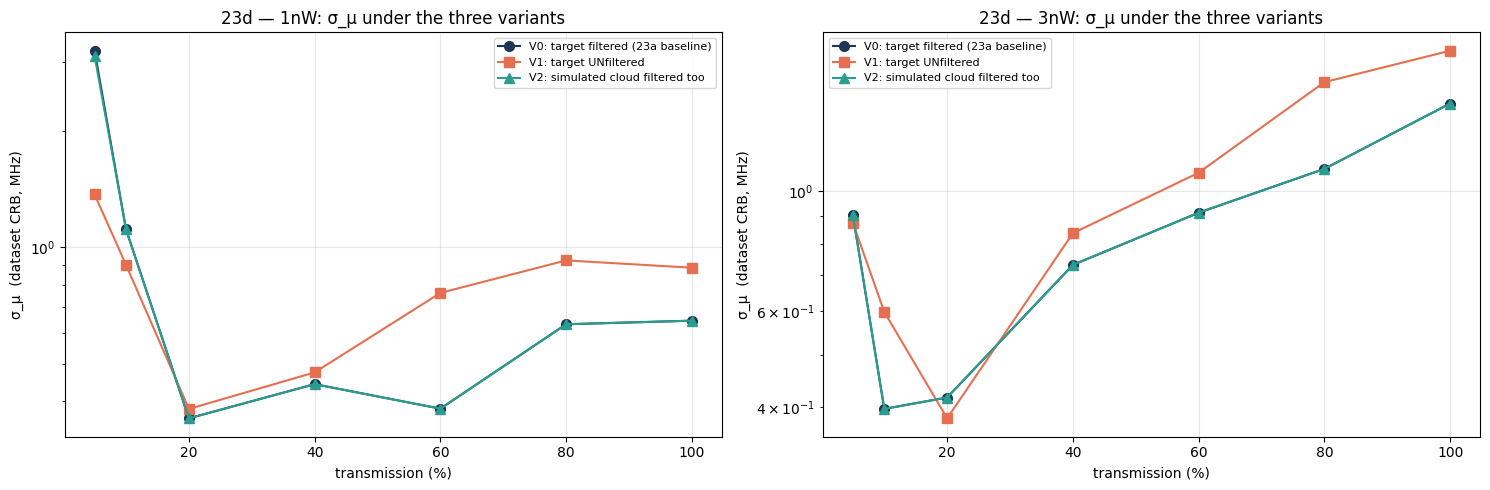

In [5]:
# ============================================================
# 23d — figure: sigma_B per variant, split by power
# ============================================================
POWERS = ['1nW', '3nW']
STY = {'V0': ('#1d3557', 'o', 'V0: target filtered (23a baseline)'),
       'V1': ('#e76f51', 's', 'V1: target UNfiltered'),
       'V2': ('#2a9d8f', '^', 'V2: simulated cloud filtered too')}
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, power in zip(axes, POWERS):
    rs = sorted([r for r in ROWS if r['exp'].startswith(power)], key=lambda r: int(r['exp'].split('Trans')[-1]))
    xs = [int(r['exp'].split('Trans')[-1]) for r in rs]
    for v, (c, m, lab) in STY.items():
        ax.plot(xs, [r[v]['sig_mu_data'] for r in rs], m + '-', color=c, ms=7, label=lab)
    ax.set_yscale('log'); ax.set_xlabel('transmission (%)'); ax.set_ylabel('σ_μ  (dataset CRB, MHz)')
    ax.set_title(f'23d — {power}: σ_μ under the three variants'); ax.grid(alpha=0.3); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


In [6]:
# ============================================================
# 23d — save the diagnostic + a short verdict summary
# ============================================================
json.dump(dict(notebook='23d-sigma-collapse-attribution', baseline='23a optima (exp6 trial_07)',
               M_FINAL=M_FINAL, FISHER_SEEDS=FISHER_SEEDS,
               variants=dict(V0='target filtered, sim unfiltered (23a)',
                             V1='target UNfiltered, sim unfiltered',
                             V2='target filtered, sim filtered by the same rule'),
               rows=ROWS), open(OUT, 'w'))
print('saved', OUT, f'({os.path.getsize(OUT)/1e6:.2f} MB)')


saved /home/pukky/.openclaw/workspace/qm-ml/data/processed/23d_sigma_collapse.json (0.01 MB)


## Notes
- The optimum (μ̂, γ̂) is **fixed** to 23a's; only the two clouds' treatment changes, so V0 must reproduce
  23a's recorded `sig_mu_data` (it does, up to the MC noise of M_FINAL × FISHER_SEEDS).
- The **simulated** `σ_fit` is our analytic CRLB, which is far smaller than the *recorded* fit error — so the
  same `σ/f < 10` rule that removes 33–62 % of the real low-T rows removes almost nothing from the simulation.
  That asymmetry is the finding, not a bug.
- Read V1 as "how much of σ is caused by conditioning the target on fit quality", and V2 as "what a like-for-like
  (symmetric) filter would do".